In [1]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\Version-Control-System-Practical-Assignment\DataCoSupplyChainDataset.csv", encoding="unicode_escape")

# Reduce dataset size so the code runs faster
df = df.sample(n=10000, random_state=42)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
df.head()

Dataset loaded successfully.
Shape of dataset: (10000, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
80120,TRANSFER,5,4,11.090000,175.990005,Late delivery,1,48,Water Sports,Caguas,...,90036.0,1073,48,NaN,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.990005,0,4/6/2016 21:05,Standard Class
19670,PAYMENT,2,1,9.800000,245.000000,Late delivery,1,24,Women's Apparel,Florissant,...,NaN,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,6/11/2017 18:43,First Class
114887,TRANSFER,2,4,117.550003,244.899994,Advance shipping,0,46,Indoor/Outdoor Games,Carmichael,...,NaN,1014,46,NaN,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.980000,0,1/4/2015 14:32,Standard Class
120110,TRANSFER,5,4,118.430000,251.979996,Late delivery,1,43,Camping & Hiking,Troy,...,NaN,957,43,NaN,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.980011,0,1/15/2017 1:46,Standard Class
56658,DEBIT,2,4,-21.590000,107.970001,Advance shipping,0,29,Shop By Sport,Caguas,...,NaN,627,29,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,4/8/2017 7:15,Standard Class


In [3]:
df["FRAUD"] = (df["Order Status"] == "SUSPECTED_FRAUD").astype(int)
df["LATE_DELIVERY"] = (df["Delivery Status"] == "Late delivery").astype(int)

print("Target variables created successfully.")
df[["FRAUD", "LATE_DELIVERY"]].head()

Target variables created successfully.


,FRAUD,LATE_DELIVERY
80120,0,1
19670,0,1
114887,0,0
120110,0,1
56658,0,0


In [4]:
features = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer",
    "Order Item Discount",
    "Order Item Quantity",
    "Product Price"
]

available_features = [f for f in features if f in df.columns]
print("Available features:", available_features)

X = df[available_features].fillna(0)
X.head()

Available features: ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Order Item Discount', 'Order Item Quantity', 'Product Price']


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Order Item Discount,Order Item Quantity,Product Price
80120,5,4,11.090000,175.990005,24.0,1,199.990005
19670,2,1,9.800000,245.000000,5.0,5,50.000000
114887,2,4,117.550003,244.899994,5.0,5,49.980000
120110,5,4,118.430000,251.979996,48.0,1,299.980011
56658,2,4,-21.590000,107.970001,12.0,3,39.990002


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully.")
print("Scaled feature shape:", X_scaled.shape)

Features scaled successfully.
Scaled feature shape: (10000, 7)


In [6]:
print("----- FRAUD DETECTION -----")

y_fraud = df["FRAUD"]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_scaled,
    y_fraud,
    test_size=0.3,
    random_state=42,
    stratify=y_fraud
)

print("Data split done for fraud detection.")
print("Training SVM for fraud detection...")

start_time = time.time()

svm_fraud = SVC(kernel="rbf", random_state=42, class_weight="balanced")
svm_fraud.fit(Xf_train, yf_train)

train_time_fraud = time.time() - start_time
print("Training finished for fraud detection.")

yf_pred = svm_fraud.predict(Xf_test)

accuracy_f = accuracy_score(yf_test, yf_pred)
precision_f = precision_score(yf_test, yf_pred, zero_division=0)
recall_f = recall_score(yf_test, yf_pred, zero_division=0)
f1_f = f1_score(yf_test, yf_pred, zero_division=0)

print("Fraud Detection Results")
print("Training Time:", round(train_time_fraud, 2), "seconds")
print("Accuracy:", round(accuracy_f * 100, 2), "%")
print("Precision:", round(precision_f * 100, 2), "%")
print("Recall:", round(recall_f * 100, 2), "%")
print("F1 Score:", round(f1_f * 100, 2), "%")

----- FRAUD DETECTION -----
Data split done for fraud detection.
Training SVM for fraud detection...
Training finished for fraud detection.
Fraud Detection Results
Training Time: 3.11 seconds
Accuracy: 47.23 %
Precision: 2.39 %
Recall: 56.72 %
F1 Score: 4.58 %


In [7]:
print("----- FRAUD DETECTION -----")

y_fraud = df["FRAUD"]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_scaled,
    y_fraud,
    test_size=0.3,
    random_state=42,
    stratify=y_fraud
)

print("Data split done for fraud detection.")
print("Training SVM for fraud detection...")

start_time = time.time()

svm_fraud = SVC(kernel="rbf", random_state=42, class_weight="balanced")
svm_fraud.fit(Xf_train, yf_train)

train_time_fraud = time.time() - start_time
print("Training finished for fraud detection.")

yf_pred = svm_fraud.predict(Xf_test)

accuracy_f = accuracy_score(yf_test, yf_pred)
precision_f = precision_score(yf_test, yf_pred, zero_division=0)
recall_f = recall_score(yf_test, yf_pred, zero_division=0)
f1_f = f1_score(yf_test, yf_pred, zero_division=0)

print("Fraud Detection Results")
print("Training Time:", round(train_time_fraud, 2), "seconds")
print("Accuracy:", round(accuracy_f * 100, 2), "%")
print("Precision:", round(precision_f * 100, 2), "%")
print("Recall:", round(recall_f * 100, 2), "%")
print("F1 Score:", round(f1_f * 100, 2), "%")

----- FRAUD DETECTION -----
Data split done for fraud detection.
Training SVM for fraud detection...
Training finished for fraud detection.
Fraud Detection Results
Training Time: 3.04 seconds
Accuracy: 47.23 %
Precision: 2.39 %
Recall: 56.72 %
F1 Score: 4.58 %


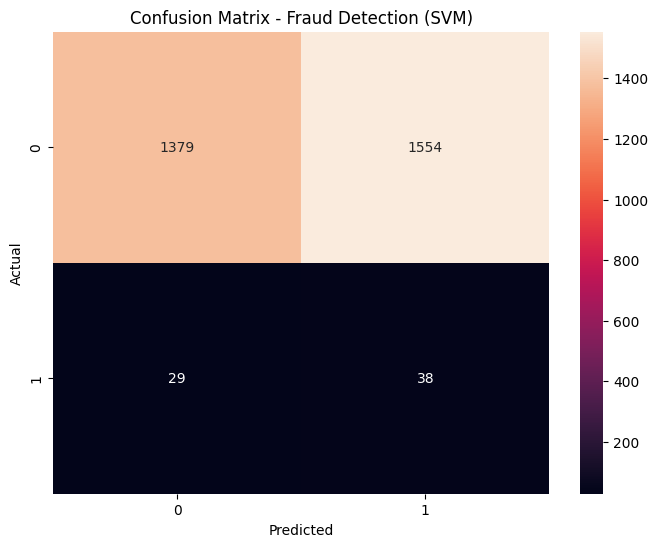

In [8]:
cm_fraud = confusion_matrix(yf_test, yf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_fraud, annot=True, fmt="d")
plt.title("Confusion Matrix - Fraud Detection (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("wendy_fraud_cm.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print("----- LATE DELIVERY PREDICTION -----")

y_late = df["LATE_DELIVERY"]

Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    X_scaled,
    y_late,
    test_size=0.3,
    random_state=42,
    stratify=y_late
)

print("Data split done for late delivery.")
print("Training SVM for late delivery...")

start_time = time.time()

svm_late = SVC(kernel="rbf", random_state=42)
svm_late.fit(Xl_train, yl_train)

train_time_late = time.time() - start_time
print("Training finished for late delivery.")

yl_pred = svm_late.predict(Xl_test)

accuracy_l = accuracy_score(yl_test, yl_pred)
precision_l = precision_score(yl_test, yl_pred, zero_division=0)
recall_l = recall_score(yl_test, yl_pred, zero_division=0)
f1_l = f1_score(yl_test, yl_pred, zero_division=0)

print("Late Delivery Results")
print("Training Time:", round(train_time_late, 2), "seconds")
print("Accuracy:", round(accuracy_l * 100, 2), "%")
print("Precision:", round(precision_l * 100, 2), "%")
print("Recall:", round(recall_l * 100, 2), "%")
print("F1 Score:", round(f1_l * 100, 2), "%")

----- LATE DELIVERY PREDICTION -----
Data split done for late delivery.
Training SVM for late delivery...
Training finished for late delivery.
Late Delivery Results
Training Time: 0.68 seconds
Accuracy: 96.93 %
Precision: 95.14 %
Recall: 99.52 %
F1 Score: 97.28 %


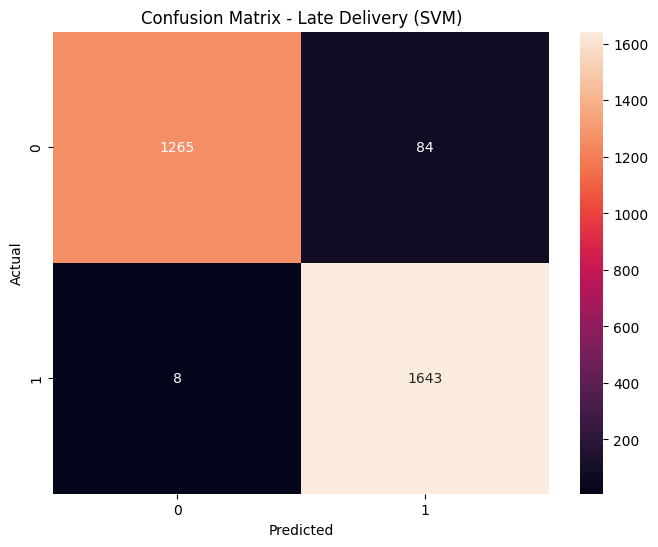

In [10]:
cm_late = confusion_matrix(yl_test, yl_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_late, annot=True, fmt="d")
plt.title("Confusion Matrix - Late Delivery (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("wendy_late_cm.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
print("----- SALES PREDICTION -----")

y_sales = df["Sales"]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_scaled,
    y_sales,
    test_size=0.3,
    random_state=42
)

print("Data split done for sales.")
print("Training LinearSVR for sales prediction...")

start_time = time.time()

svr_sales = LinearSVR(random_state=42, max_iter=5000)
svr_sales.fit(Xs_train, ys_train)

train_time_sales = time.time() - start_time
print("Training finished for sales prediction.")

ys_pred = svr_sales.predict(Xs_test)

mae_sales = mean_absolute_error(ys_test, ys_pred)
rmse_sales = np.sqrt(mean_squared_error(ys_test, ys_pred))

print("Sales Prediction Results")
print("Training Time:", round(train_time_sales, 2), "seconds")
print("MAE:", round(mae_sales, 4))
print("RMSE:", round(rmse_sales, 4))

----- SALES PREDICTION -----
Data split done for sales.
Training LinearSVR for sales prediction...
Training finished for sales prediction.
Sales Prediction Results
Training Time: 0.68 seconds
MAE: 0.0015
RMSE: 0.0021


In [12]:
print("----- QUANTITY PREDICTION -----")

y_qty = df["Order Item Quantity"]

Xq_train, Xq_test, yq_train, yq_test = train_test_split(
    X_scaled,
    y_qty,
    test_size=0.3,
    random_state=42
)

print("Data split done for quantity.")
print("Training LinearSVR for quantity prediction...")

start_time = time.time()

svr_qty = LinearSVR(random_state=42, max_iter=5000)
svr_qty.fit(Xq_train, yq_train)

train_time_qty = time.time() - start_time
print("Training finished for quantity prediction.")

yq_pred = svr_qty.predict(Xq_test)

mae_qty = mean_absolute_error(yq_test, yq_pred)
rmse_qty = np.sqrt(mean_squared_error(yq_test, yq_pred))

print("Quantity Prediction Results")
print("Training Time:", round(train_time_qty, 2), "seconds")
print("MAE:", round(mae_qty, 4))
print("RMSE:", round(rmse_qty, 4))

----- QUANTITY PREDICTION -----
Data split done for quantity.
Training LinearSVR for quantity prediction...
Training finished for quantity prediction.
Quantity Prediction Results
Training Time: 0.0 seconds
MAE: 0.0
RMSE: 0.0


In [13]:
results = {
    "Task": [
        "Fraud Detection",
        "Late Delivery",
        "Sales Prediction",
        "Quantity Prediction"
    ],
    "Accuracy (%)": [
        round(accuracy_f * 100, 2),
        round(accuracy_l * 100, 2),
        "N/A",
        "N/A"
    ],
    "Precision (%)": [
        round(precision_f * 100, 2),
        round(precision_l * 100, 2),
        "N/A",
        "N/A"
    ],
    "Recall (%)": [
        round(recall_f * 100, 2),
        round(recall_l * 100, 2),
        "N/A",
        "N/A"
    ],
    "F1-Score (%)": [
        round(f1_f * 100, 2),
        round(f1_l * 100, 2),
        "N/A",
        "N/A"
    ],
    "MAE": [
        "N/A",
        "N/A",
        round(mae_sales, 4),
        round(mae_qty, 4)
    ],
    "RMSE": [
        "N/A",
        "N/A",
        round(rmse_sales, 4),
        round(rmse_qty, 4)
    ],
    "Training Time (s)": [
        round(train_time_fraud, 2),
        round(train_time_late, 2),
        round(train_time_sales, 2),
        round(train_time_qty, 2)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Task,Accuracy (%),Precision (%),Recall (%),F1-Score (%),MAE,RMSE,Training Time (s)
0,Fraud Detection,47.23,2.39,56.72,4.58,N/A,N/A,3.04
1,Late Delivery,96.93,95.14,99.52,97.28,N/A,N/A,0.68
2,Sales Prediction,N/A,N/A,N/A,N/A,0.0015,0.0021,0.68
3,Quantity Prediction,N/A,N/A,N/A,N/A,0.0,0.0,0.00


In [2]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df.to_csv('wendy_svm_results.csv', index=False)
print("\n✅ Results saved to 'wendy_svm_results.csv'")

NameError: name 'results' is not defined

In [3]:
import os
print("Current directory:", os.getcwd())
print("File exists:", os.path.exists('wendy_svm_results.csv'))
print("Full path:", os.path.abspath('wendy_svm_results.csv'))

Current directory: C:\Users\Admin\documents
File exists: True
Full path: C:\Users\Admin\documents\wendy_svm_results.csv


In [4]:
# Read and display the CSV
import pandas as pd
df = pd.read_csv('wendy_svm_results.csv')
display(df)


,Task,Accuracy (%),Precision (%),Recall (%),F1-Score (%),MAE,RMSE,Training Time (s)
0,Fraud Detection,47.23,2.39,56.72,4.58,NaN,NaN,3.04
1,Late Delivery,96.93,95.14,99.52,97.28,NaN,NaN,0.68
2,Sales Prediction,NaN,NaN,NaN,NaN,0.0015,0.0021,0.68
3,Quantity Prediction,NaN,NaN,NaN,NaN,0.0000,0.0000,0.00
